# ICT606 Assignment 2 Part 2

## PART A - Dataset understanding
#### Load the dataset

In [1]:
import numpy as np
import pandas as pd

# Loading the dataset
reddit_df = pd.read_csv('data/the-reddit-dataset-dataset-comments.csv', sep=',', header=0, encoding='utf-8')

#### Dataset describe

In [2]:
reddit_df.describe()

,created_utc,sentiment,score
count,5.484800e+04,47370.000000,54848.000000
mean,1.540431e+09,0.296796,2.019344
std,7.507744e+07,0.435143,3.201183
min,1.270456e+09,-0.999100,-65.000000
25%,1.490050e+09,0.000000,1.000000
50%,1.559056e+09,0.361200,1.000000
75%,1.598566e+09,0.670500,2.000000
max,1.646174e+09,0.999900,195.000000


#### Dataset info

In [3]:
reddit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54848 entries, 0 to 54847
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   type            54848 non-null  object 
 1   id              54848 non-null  object 
 2   subreddit.id    54848 non-null  object 
 3   subreddit.name  54848 non-null  object 
 4   subreddit.nsfw  54848 non-null  bool   
 5   created_utc     54848 non-null  int64  
 6   permalink       54848 non-null  object 
 7   body            54846 non-null  object 
 8   sentiment       47370 non-null  float64
 9   score           54848 non-null  int64  
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 3.8+ MB


#### First 5 rows

In [4]:
reddit_df.head()

,type,id,subreddit.id,subreddit.name,subreddit.nsfw,created_utc,permalink,body,sentiment,score
0,comment,hyyz6g8,2r97t,datasets,False,1646173750,https://old.reddit.com/r/datasets/comments/t45...,Spatial problem: Suitability of new locations ...,0.0772,1
1,comment,hyyid7v,2r97t,datasets,False,1646167280,https://old.reddit.com/r/datasets/comments/sg9...,Have you tried toying around with GDELT or Ali...,0.0000,2
2,comment,hyxp1qp,2r97t,datasets,False,1646156018,https://old.reddit.com/r/datasets/comments/t44...,Damn random internet person of whom I know not...,-0.3851,3
3,comment,hyxgnyu,2r97t,datasets,False,1646152782,https://old.reddit.com/r/datasets/comments/t44...,Ah nice one. Best of luck with the baby. If yo...,0.9136,3
4,comment,hyxfjw6,2r97t,datasets,False,1646152345,https://old.reddit.com/r/datasets/comments/t49...,I was about to write and say this shouldn't be...,0.0762,2


For topic modelling, we are interested in the text column 'body'.

Note: Body type is object. so need to convert it to string.

#### Analyse the length of the comments.

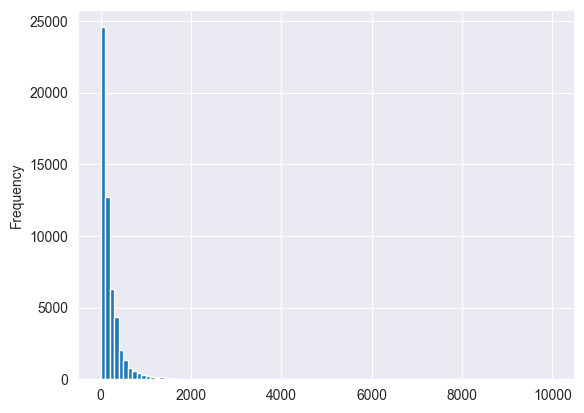

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df = reddit_df.copy()
df['body'] = df['body'].astype(str)
df['length'] = df['body'].apply(len)
df['length'].plot(bins=100, kind='hist')
plt.show()

Length statistics

In [6]:
df['length'].describe()

count    54848.000000
mean       212.262598
std        351.833236
min          1.000000
25%         46.000000
50%        118.000000
75%        253.000000
max       9979.000000
Name: length, dtype: float64

Rows where length is less than 10.

In [7]:
print((df['body'].str.len() < 10).sum())

4901


## PART B & C
#### Text preprocessing
In this part we will preprocess the text cleanup any html tags, emoticons, hashtags, urls, mentions.
#### In feature engineering,
1. First we remove stopwords.
2. Then we remove non-ASCII characters.
3. Then we remove spaces, punctuation, and special characters.
4. Finally we will lemmatize the words.

In [8]:
import re
import html
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def ensure_stopwords():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

def ensure_wordnet():
    try:
        nltk.data.find('corpora/wordnet')
    except LookupError:
        nltk.download('wordnet')

ensure_stopwords()
ensure_wordnet()

stop_words = set(stopwords.words('english'))

def preprocessor(text):
    # PART B - Text Preprocessing
    # -----------------------------------------------------
    # Remove HTML tags
    text = html.unescape(text)
    text = re.sub(r'<[^>]*>', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Handle hashtags
    text = re.sub(r'#(\w+)', r'\1', text)

    # Extract Emoticons
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)

    # Normalize text
    text = text.lower()
    text = re.sub(r'[\W]+', ' ', text)

    # Remove non-ASCII
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Remove emoticons
    text = text + ' ' + ' '.join(emoticons).replace('-', '')

    # PART C - Feature Engineering
    # Remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]

    tokens = [w for w in tokens if w.isalnum()]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return ' '.join(tokens)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\durlo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Printing the largest text before and after preprocessing.

In [9]:
row = df.loc[df['length'].idxmax()]
print('Before preprocessing:')
print(row['body'][:300])

cleaned_text = preprocessor(row['body'][:300])
print('After preprocessing:')
print(cleaned_text)

Before preprocessing:
I had planned on doing some more analysis with these, but work is calling to me. I uploaded the raw data [here](http://www.filedropper.com/statecounts), if anyone wants to take a peek.

You may remember me from similar posts I made in [/r/NFL](http://imgur.com/a/oIqbn) and [/r/Baseball](http://imgur
After preprocessing:
planned analysis work calling uploaded raw data anyone want take peek may remember similar post made r nfl r baseball


#### Apply preprocess

In [10]:
df['processed'] = df['body'].apply(preprocessor)

#### Sampling
We choose 2000 rows for the topic modeling because topic modeling is computation heavy.

In [11]:
# First we drop rows where length is less than 10 words.
df = df[df['processed'].astype(str).str.split().str.len() >= 10]
df_sample = df.sample(n=3000, random_state=30)

X = df_sample['processed']

# Print first 5 rows
X.head()

11310    covid case u county level daily social data we...
10664    anyone know emerging vaccination datasets like...
53518    first link general piracy find rdf file actual...
10602    data useless since whole new world covid nothi...
26439    data retains core statistical property think r...
Name: processed, dtype: object

## PART D - BERTopic model development

Helper method to print coherence

In [12]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_colab():
    !pip install gensim

import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel


def print_topic_coherence(
        model,
        documents,
        coherence="c_v",
        top_n_words=10,
        max_topics=None,
        exclude_outlier=True
):
    # Convert documents to list of strings
    documents = [str(doc) for doc in documents]

    cleaned_docs = model._preprocess_text(documents)

    vectorizer = model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    tokens = [analyzer(doc) for doc in cleaned_docs]

    topics = model.get_topics().copy()
    if exclude_outlier:
        topics.pop(-1, None)

    topic_words = []

    for topic_id, words_scores in topics.items():
        if exclude_outlier and topic_id == -1:
            continue

        words = [
            word
            for word, score in words_scores[:top_n_words]
            if word != ""
        ]

        if words:
            topic_words.append(words)

        if max_topics is not None and len(topic_words) >= max_topics:
            break

    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens,
        corpus=corpus,
        dictionary=dictionary,
        coherence=coherence
    )

    coherence_score = coherence_model.get_coherence()

    print(f"Number of topics evaluated: {len(topic_words)}")
    print(f"Top words per topic: {top_n_words}")
    print(f"Coherence Score ({coherence}): {coherence_score}")

    return coherence_score

In [13]:
from bertopic import BERTopic
import torch
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cuda" if torch.cuda.is_available() else "cpu" # Ensuring it works for both CPU and GPU
)

def tune():
    vectorizers = [
        CountVectorizer(stop_words="english", min_df=1, max_df=0.95, ngram_range=(1, 1)),
        CountVectorizer(stop_words="english", min_df=1, max_df=0.95, ngram_range=(1, 2)),
        CountVectorizer(stop_words="english", min_df=2, max_df=0.9, ngram_range=(1, 2)),
        CountVectorizer(stop_words="english", min_df=3, max_df=0.9, ngram_range=(1, 2)),
    ]

    results = []

    for nr_topics in [10, 20, 40, 50, 'auto', None]:
        for vectorizer in vectorizers:
            topic_model = BERTopic(
                embedding_model=embedding_model,
                vectorizer_model=vectorizer,
                language="english",
                calculate_probabilities=True,
                nr_topics=nr_topics,
                verbose=True
            )

            topics, probs = topic_model.fit_transform(X.tolist())

            coherence = print_topic_coherence(
                topic_model,
                X,
                top_n_words=10
            )

            topic_info = topic_model.get_topic_info()
            n_topics = len(topic_info[topic_info["Topic"] != -1])

            outlier_count = topic_info.loc[topic_info["Topic"] == -1, "Count"].sum()
            outlier_percentage = outlier_count / len(X) * 100

            results.append({
                "vectorizer": vectorizer,
                "coherence": coherence,
                "n_topics": n_topics,
                "nr_topics": nr_topics,
                "outlier_percentage": outlier_percentage,
                "topics": topics,
                "probs": probs,
                "topic_model": topic_model
            })

    return results

results = tune()

best_result = max(results, key=lambda x: x["coherence"])
best_vectorizer = best_result["vectorizer"]
best_coherence = best_result["coherence"]
best_n_topics = best_result["n_topics"]
best_nr_topics = best_result["nr_topics"]
best_outlier_percentage = best_result["outlier_percentage"]
topics = best_result["topics"]
probs = best_result["probs"]
topic_model = best_result["topic_model"]

print(f"Best coherence: {best_coherence:.2f}")
print(f"Best number of topics: {best_n_topics}")
print(f"Best number of topics: {best_nr_topics}")
print(f"Outlier percentage: {best_outlier_percentage:.2f}%")

D:\PyCharmProjects\ICT606-Assignment2-TopicModelling-NLP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.12.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4873.74it/s]
2026-05-27 07:38:49,168 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 94/94 [00:01<00:00, 70.36it/s] 
2026-05-27 07:38:50,524 - BERTopic - Embedding - Completed ✓
2026-05-27 07:38:50,525 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 07:39:02,981 - BERTopic - Dimensionality - Completed ✓
2026-05-27 07:39:02,983 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 07:39:03,281 - BERTopic - Cluster - Completed ✓
2026-05-27 07:39:03,281 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-27 07:39:03,335 - BERTopic - Representation - Completed ✓
2026-05-27 07:39:03,335 - BERTopic - Topic reduction - Reducing number of topics
2026-05-27 07:39:03,356 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 07:39:03,401 - BERTopic - Representation - C

Number of topics evaluated: 9
Top words per topic: 10
Coherence Score (c_v): 0.6469868388329268


Batches: 100%|██████████| 94/94 [00:01<00:00, 74.89it/s] 
2026-05-27 07:39:19,229 - BERTopic - Embedding - Completed ✓
2026-05-27 07:39:19,230 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 07:39:24,425 - BERTopic - Dimensionality - Completed ✓
2026-05-27 07:39:24,425 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 07:39:24,704 - BERTopic - Cluster - Completed ✓
2026-05-27 07:39:24,705 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-27 07:39:24,875 - BERTopic - Representation - Completed ✓
2026-05-27 07:39:24,876 - BERTopic - Topic reduction - Reducing number of topics
2026-05-27 07:39:24,882 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 07:39:25,032 - BERTopic - Representation - Completed ✓
2026-05-27 07:39:25,035 - BERTopic - Topic reduction - Reduced number of topics from 49 to 10
2026-05-27 07:39:39,617 - BERTopic - Embedding - Tr

...

Number of topics evaluated: 7
Top words per topic: 10
Coherence Score (c_v): 0.9327715113008622


Batches: 100%|██████████| 94/94 [00:01<00:00, 81.16it/s] 
2026-05-27 07:46:38,856 - BERTopic - Embedding - Completed ✓
2026-05-27 07:46:38,857 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 07:46:43,495 - BERTopic - Dimensionality - Completed ✓
2026-05-27 07:46:43,496 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 07:46:43,785 - BERTopic - Cluster - Completed ✓
2026-05-27 07:46:43,787 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 07:46:43,883 - BERTopic - Representation - Completed ✓
2026-05-27 07:46:58,451 - BERTopic - Embedding - Transforming documents to embeddings.


Number of topics evaluated: 48
Top words per topic: 10
Coherence Score (c_v): 0.5231345274540419


Batches: 100%|██████████| 94/94 [00:01<00:00, 83.33it/s] 
2026-05-27 07:46:59,590 - BERTopic - Embedding - Completed ✓
2026-05-27 07:46:59,591 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-27 07:47:04,203 - BERTopic - Dimensionality - Completed ✓
2026-05-27 07:47:04,203 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-27 07:47:04,471 - BERTopic - Cluster - Completed ✓
2026-05-27 07:47:04,474 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-27 07:47:04,579 - BERTopic - Representation - Completed ✓


Number of topics evaluated: 47
Top words per topic: 10
Coherence Score (c_v): 0.4775645320202954
Best coherence: 0.93
Best number of topics: 7
Best number of topics: None
Outlier percentage: 0.70%


#### Results

BERTopic model was tuned using 4 different vectorizers. Each vectorizer was used to fit the model.

**CV1: min_df=1, max_df=0.95**
Number of topics evaluated: 239
Top words per topic: 10
Coherence Score (c_v): 0.5290599075179185

**CV2: min_df=1, max_df=0.95**
Number of topics evaluated: 243
Top words per topic: 10
Coherence Score (c_v): 0.598090230260466

**CV3: min_df=2, max_df=0.9**
Number of topics evaluated: 249
Top words per topic: 10
Coherence Score (c_v): 0.5750790706434437

**CV: min_df=3, max_df=0.9**
Number of topics evaluated: 247
Top words per topic: 10
Coherence Score (c_v): 0.5513183310421262


**Best performing model was CV2: min_df=1, max_df=0.95.**


#### Extracting topics

In [14]:
freq = topic_model.get_topic_info(); freq.head(5)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,21,-1_survey_post_sorry_feel free,"[survey, post, sorry, feel free, free, subredd...",[opinion request datasets answering question a...
1,0,2821,0_data_like_use_dataset,"[data, like, use, dataset, need, time, know, t...",[heyo thank taking time answer detail work eni...
2,1,49,1_flair_post_change post_flair appropriate,"[flair, post, change post, flair appropriate, ...",[hey kananvyas2 believe request flair might ap...
3,2,27,2_mod_post_feel free_removing,"[mod, post, feel free, removing, feel, hey, di...",[hey u u elbertgiannini removing post seem rel...
4,3,26,3_spam_reported_reported spam_spam consider,"[spam, reported, reported spam, spam consider,...",[hey irshad78 sorry removing similar submissio...


#### Select the most frequest topics

In [15]:
topic_model.get_topic(0)

[('data', np.float64(0.033548692223593746)),
 ('like', np.float64(0.013607572826228858)),
 ('use', np.float64(0.012629353656457768)),
 ('dataset', np.float64(0.011554035618925701)),
 ('need', np.float64(0.009869419791995957)),
 ('time', np.float64(0.009242690809877692)),
 ('know', np.float64(0.009177256766357566)),
 ('think', np.float64(0.009095587350127157)),
 ('want', np.float64(0.009009751547904909)),
 ('look', np.float64(0.008415217387861657))]

#### Visualisation

In [16]:
topic_model.visualize_topics()

#### Visualise topic probability

In [17]:
topic_model.visualize_distribution(probs[200], min_probability=0.005)

#### Visualise topic hierarchy

In [18]:
topic_model.visualize_hierarchy(top_n_topics=50)

#### Visualise terms

In [19]:
topic_model.visualize_barchart(top_n_topics=5)

Here topic 0 is about sprots
Topic 1 is about photos. it could be related to selfies.
topic 2 is about page scraping.
topic 3 is about weather or climate change.
topic 4 could be about crime.

#### Visualise topic similarity

In [20]:
topic_model.visualize_heatmap(n_clusters=5, width=1000, height=1000)

#### Visualise term score decline

In [21]:
topic_model.visualize_term_rank()